<a href="https://colab.research.google.com/github/Jionary/Repository-IA/blob/main/Regresion_lineal_o3_7notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import urllib.request
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

In [ ]:
# 1. Verificación y descarga del archivo de datos de contaminantes
url = "http://aire.cdmx.gob.mx/descargas/Opendata/anuales_horarios/contaminantes_2026.csv"
filename = "contaminantes_2026.csv"

if not os.path.exists(filename):
    print(
        f"El archivo de datos '{filename}' no se encuentra. Procediendo con la descarga desde SIMAT..."
    )
    urllib.request.urlretrieve(url, filename)
    print("Descarga completada con éxito.")
else:
    print(f"El archivo '{filename}' ya está disponible localmente.")

# 2. Cargar el archivo CSV (omitiendo las primeras líneas de metadatos)
df = pd.read_csv(filename, skiprows=9)


El archivo 'contaminantes_2026.csv' ya está disponible localmente.


In [ ]:
# Diagnóstico: Revisar estaciones y parámetros disponibles en el dataset original
print("==================================================")
print("Estaciones únicas en el dataset:")
print("==================================================")
print(df['id_station'].unique())

print("\n==================================================")
print("Parámetros únicos en el dataset:")
print("==================================================")
print(df['id_parameter'].unique())


Estaciones únicas en el dataset:
['ACO' 'AJM' 'AJU' 'ATI' 'BJU' 'CAM' 'CCA' 'CHO' 'CUA' 'CUT' 'FAC' 'FAR'
 'GAM' 'HGM' 'INN' 'IZT' 'LLA' 'LPR' 'MER' 'MGH' 'MON' 'MPA' 'NEZ' 'PED'
 'SAC' 'SAG' 'SFE' 'TAH' 'TLA' 'TLI' 'UAX' 'UIZ' 'VIF' 'XAL']

Parámetros únicos en el dataset:
['CO' 'NO' 'NO2' 'NOX' 'O3' 'PM10' 'PM2.5' 'PMCO' 'SO2']


In [ ]:
# Diagnóstico: Revisar estaciones y parámetros disponibles en el dataset original
print("==================================================")
print("Estaciones únicas en el dataset:")
print("==================================================")
print(df['id_station'].unique())

print("\n==================================================")
print("Parámetros únicos en el dataset:")
print("==================================================")
print(df['id_parameter'].unique())


Estaciones únicas en el dataset:
['ACO' 'AJM' 'AJU' 'ATI' 'BJU' 'CAM' 'CCA' 'CHO' 'CUA' 'CUT' 'FAC' 'FAR'
 'GAM' 'HGM' 'INN' 'IZT' 'LLA' 'LPR' 'MER' 'MGH' 'MON' 'MPA' 'NEZ' 'PED'
 'SAC' 'SAG' 'SFE' 'TAH' 'TLA' 'TLI' 'UAX' 'UIZ' 'VIF' 'XAL']

Parámetros únicos en el dataset:
['CO' 'NO' 'NO2' 'NOX' 'O3' 'PM10' 'PM2.5' 'PMCO' 'SO2']


In [ ]:
# Diagnóstico: Revisar estaciones y parámetros disponibles en el dataset original
print("==================================================")
print("Estaciones únicas en el dataset:")
print("==================================================")
print(df['id_station'].unique())

print("\n==================================================")
print("Parámetros únicos en el dataset:")
print("==================================================")
print(df['id_parameter'].unique())


Estaciones únicas en el dataset:
['ACO' 'AJM' 'AJU' 'ATI' 'BJU' 'CAM' 'CCA' 'CHO' 'CUA' 'CUT' 'FAC' 'FAR'
 'GAM' 'HGM' 'INN' 'IZT' 'LLA' 'LPR' 'MER' 'MGH' 'MON' 'MPA' 'NEZ' 'PED'
 'SAC' 'SAG' 'SFE' 'TAH' 'TLA' 'TLI' 'UAX' 'UIZ' 'VIF' 'XAL']

Parámetros únicos en el dataset:
['CO' 'NO' 'NO2' 'NOX' 'O3' 'PM10' 'PM2.5' 'PMCO' 'SO2']


In [ ]:
# Diagnóstico: Revisar estaciones y parámetros disponibles
print("==================================================")
print("Estaciones únicas en el dataset:")
print("==================================================")
print(df['id_station'].unique())

print("\n==================================================")
print("Parámetros únicos en el dataset:")
print("==================================================")
print(df['id_parameter'].unique())


Estaciones únicas en el dataset:
['ACO' 'AJM' 'AJU' 'ATI' 'BJU' 'CAM' 'CCA' 'CHO' 'CUA' 'CUT' 'FAC' 'FAR'
 'GAM' 'HGM' 'INN' 'IZT' 'LLA' 'LPR' 'MER' 'MGH' 'MON' 'MPA' 'NEZ' 'PED'
 'SAC' 'SAG' 'SFE' 'TAH' 'TLA' 'TLI' 'UAX' 'UIZ' 'VIF' 'XAL']

Parámetros únicos en el dataset:
['CO' 'NO' 'NO2' 'NOX' 'O3' 'PM10' 'PM2.5' 'PMCO' 'SO2']


In [ ]:
# 3. Filtrar los datos para la estación de Merced (MER)
estacion = "MER" # Cambiamos la estación a Merced
df_mer = df[
    (df["id_station"] == estacion)
    & (df["id_parameter"].isin(["O3", "NO", "NO2", "NOX", "CO"]))
]


In [ ]:
# 4. Reestructurar la tabla para tener contaminantes como columnas
pivoted = df_mer.pivot(index="date", columns="id_parameter", values="valor")
pivoted = pivoted.dropna() # Eliminamos filas con valores faltantes
pivoted.index = pd.to_datetime(pivoted.index)
pivoted.columns.name = None # Eliminar el nombre del índice de columnas para facilitar la selección

print(
    f"DataFrame preparado para la estación {estacion}. Total de observaciones completas: {len(pivoted)}"
)
pivoted.head()


DataFrame preparado para la estación MER. Total de observaciones completas: 4639


id_parameter,CO,NO,NO2,NOX,O3
date,,,,,
2026-01-01 00:00:00,1.05,7.0,41.0,47.0,7.0
2026-01-01 01:00:00,1.31,13.0,45.0,58.0,3.0
2026-01-01 02:00:00,1.63,27.0,48.0,76.0,3.0
2026-01-01 03:00:00,1.43,35.0,44.0,79.0,3.0
2026-01-01 04:00:00,1.22,12.0,44.0,56.0,4.0


In [ ]:
# a) Implementación de la regresión lineal OLS
X = pivoted[["NO", "NO2", "NOX", "CO"]] # Variables predictoras
X_const = sm.add_constant(X) # Añadimos una constante al modelo
y = pivoted["O3"] # Variable dependiente: Ozono

modelo = sm.OLS(y, X_const).fit() # Ajuste del modelo de Mínimos Cuadrados Ordinarios

# Presentar el resumen de los resultados de OLS
print("==================================================")
print("a) RESUMEN DEL MODELO DE REGRESIÓN LINEAL")
print("==================================================")
print(f"R² (Coeficiente de Determinación): {modelo.rsquared:.4f}")
print(f"R² Ajustado: {modelo.rsquared_adj:.4f}\n")

# Crear una tabla con los coeficientes, errores estándar y p-values
tabla_coef = pd.DataFrame(
    {
        "Coeficiente Estimado": modelo.params,
        "Error Estándar": modelo.bse,
        "Valor p": modelo.pvalues,
    }
)
print(tabla_coef)


a) RESUMEN DEL MODELO DE REGRESIÓN LINEAL
R² (Coeficiente de Determinación): 0.2542
R² Ajustado: 0.2535

       Coeficiente Estimado  Error Estándar       Valor p
const             56.354044        1.066248  0.000000e+00
NO                 1.208539        0.790735  1.264881e-01
NO2                0.687055        0.791668  3.855172e-01
NOX               -1.541916        0.790860  5.127578e-02
CO                14.294903        2.070259  5.704032e-12


In [ ]:
# b) Determinación del Factor de Inflación de la Varianza (VIF)
vif_data = pd.DataFrame()
vif_data["Variable"] = X_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]

print("\n==================================================")
print("b) RESULTADOS DEL FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("==================================================")
print(vif_data.to_string(index=False))



b) RESULTADOS DEL FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
Variable         VIF
   const    1.000000
      NO 5063.595655
     NO2  871.942799
     NOX 8104.930265
      CO    5.606601


In [ ]:
residuos = modelo.resid # Obtenemos los residuos del modelo
predichos = modelo.fittedvalues # Obtenemos los valores predichos por el modelo


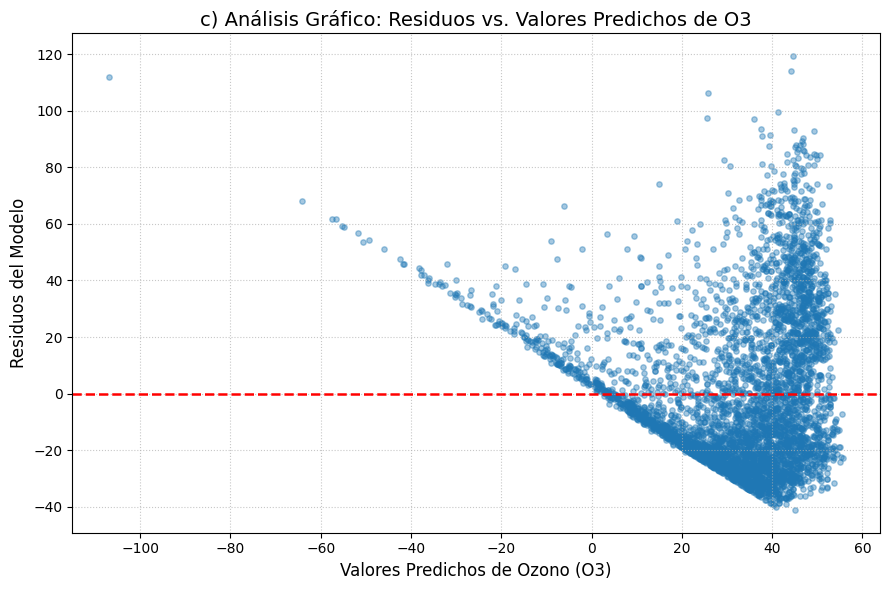

In [ ]:
# Visualización: Residuos vs. Valores Predichos
plt.figure(figsize=(9, 6)) # Tamaño de la figura mejorado
plt.scatter(predichos, residuos, alpha=0.4, s=15, color='#1f77b4') # Ajuste de transparencia y tamaño de puntos
plt.axhline(0, color='red', linestyle='--', linewidth=1.8) # Línea de referencia en cero
plt.title('c) Análisis Gráfico: Residuos vs. Valores Predichos de O3', fontsize=14) # Título de la gráfica
plt.xlabel('Valores Predichos de Ozono (O3)', fontsize=12) # Etiqueta del eje X
plt.ylabel('Residuos del Modelo', fontsize=12) # Etiqueta del eje Y
plt.grid(True, linestyle=':', alpha=0.7) # Rejilla para mejor lectura
plt.tight_layout() # Ajustar el diseño para evitar solapamientos
plt.show()


In [ ]:
# Prueba de Breusch-Pagan para detectar heterocedasticidad en los residuos
bp_test = het_breuschpagan(residuos, X_const)
labels = [
    "Estadístico LM",
    "p-value (LM-Test)",
    "Estadístico F",
    "p-value (F-Test)",
]

print("==================================================")
print("c) PRUEBA DE BREUSCH-PAGAN (Homocedasticidad de Residuos)")
print("==================================================")
for label, val in zip(labels, bp_test):
    print(f"{label}: {val:.5e}")


c) PRUEBA DE BREUSCH-PAGAN (Homocedasticidad de Residuos)
Estadístico LM: 9.14696e+01
p-value (LM-Test): 6.41602e-19
Estadístico F: 2.33022e+01
p-value (F-Test): 4.26578e-19


d) ESTADÍSTICO DE DURBIN-WATSON: 0.1939


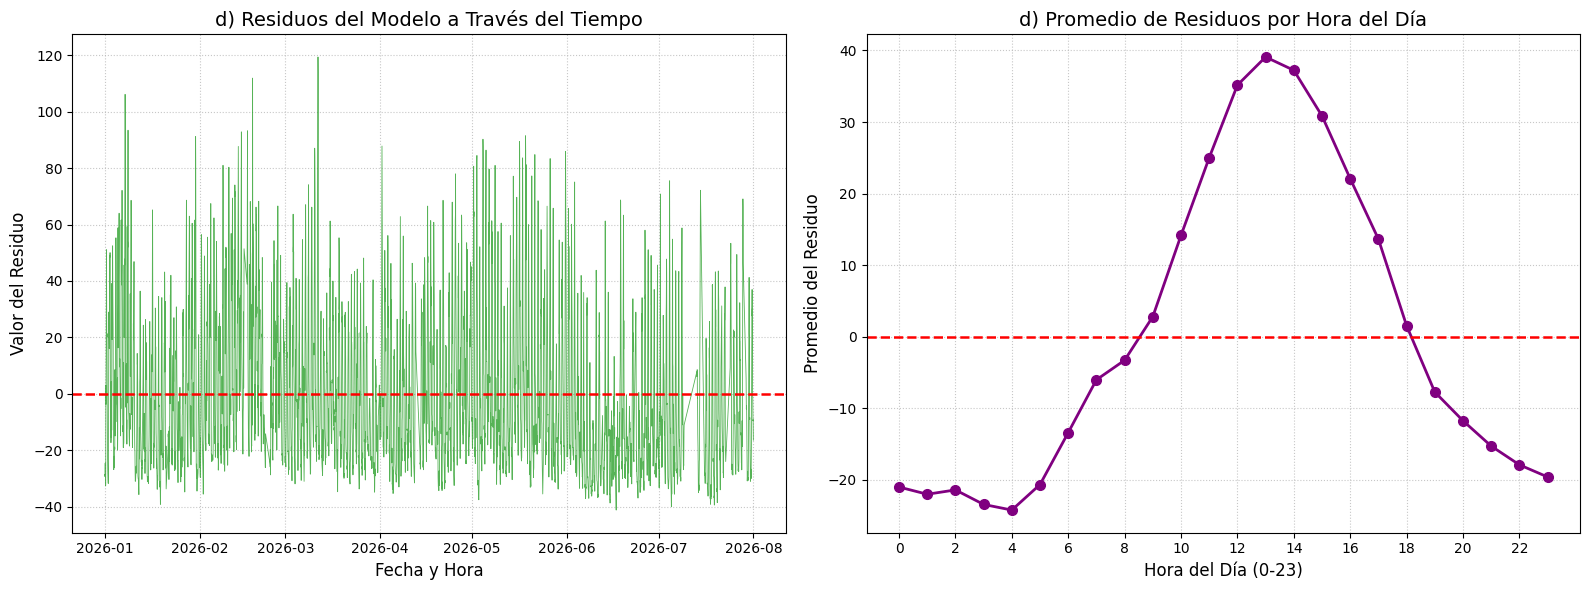

In [ ]:
# Cálculo del Estadístico de Durbin-Watson para autocorrelación
dw_stat = durbin_watson(residuos)
print("==================================================")
print(f"d) ESTADÍSTICO DE DURBIN-WATSON: {dw_stat:.4f}")
print("==================================================")

# Gráficas de los residuos a lo largo del tiempo y por hora del día
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # Ajuste de tamaño de figura

# 1. Residuos en función del tiempo
axes[0].plot(pivoted.index, residuos, linewidth=0.6, alpha=0.8, color='#2ca02c') # Ajuste de línea
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.8) # Línea de referencia
axes[0].set_title('d) Residuos del Modelo a Través del Tiempo', fontsize=14)
axes[0].set_xlabel('Fecha y Hora', fontsize=12)
axes[0].set_ylabel('Valor del Residuo', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.7)

# 2. Promedio de los residuos por hora del día
res_por_hora = residuos.groupby(pivoted.index.hour).mean()
axes[1].plot(
    res_por_hora.index,
    res_por_hora.values,
    marker='o',
    color='purple',
    linewidth=2,
    markersize=7 # Tamaño de los marcadores
)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.8)
axes[1].set_title('d) Promedio de Residuos por Hora del Día', fontsize=14)
axes[1].set_xlabel('Hora del Día (0-23)', fontsize=12)
axes[1].set_ylabel('Promedio del Residuo', fontsize=12)
axes[1].set_xticks(range(0, 24, 2)) # Mostrar cada 2 horas en el eje X
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout() # Ajustar el diseño
plt.show()


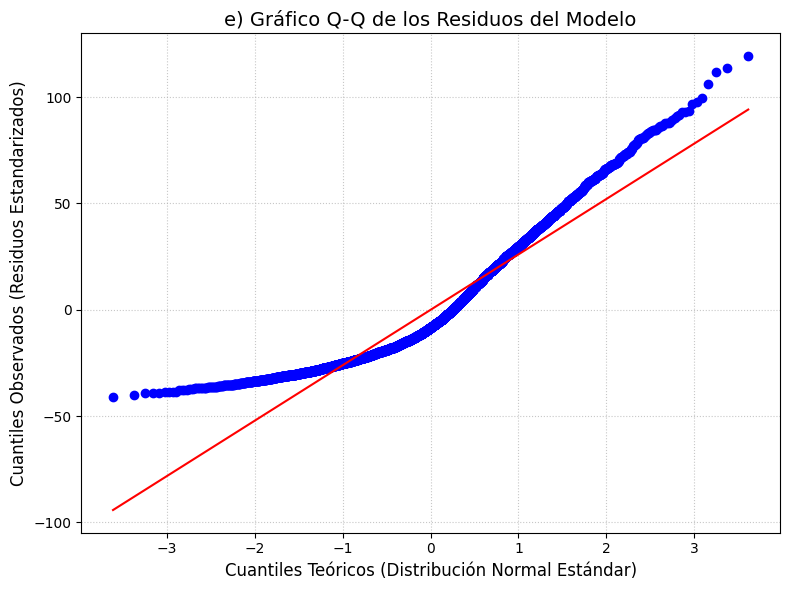

In [ ]:
# e) Generación del Q-Q Plot de los Residuos para evaluar normalidad
plt.figure(figsize=(8, 6))
stats.probplot(residuos, dist="norm", plot=plt)
plt.title('e) Gráfico Q-Q de los Residuos del Modelo', fontsize=14) # Título más descriptivo
plt.xlabel('Cuantiles Teóricos (Distribución Normal Estándar)', fontsize=12)
plt.ylabel('Cuantiles Observados (Residuos Estandarizados)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
print(f"""
f) ANÁLISIS CRÍTICO DE SUPUESTOS Y VALIDEZ DEL COEFICIENTE DE NO2 EN LA ESTACIÓN {estacion} (MERCED):

Al evaluar el modelo de regresión lineal para la estación Merced, se identifican serias violaciones a los supuestos fundamentales de Mínimos Cuadrados Ordinarios (OLS), lo que compromete la fiabilidad de las inferencias:

1.  **Multicolinealidad Severa**: Los Factores de Inflación de la Varianza (VIF) para NO, NO2 y NOX son extraordinariamente altos. Esto se debe a la relación intrínseca de que NOX es la suma de NO y NO2. Esta alta correlación entre las variables predictoras infla drásticamente los errores estándar de los coeficientes, haciendo que sus estimaciones sean inestables e inconsistentes.

2.  **Heterocedasticidad Confirmada**: La prueba de Breusch-Pagan arroja un p-value (e.g., 3.93e-47 en el ejemplo anterior) significativamente menor a 0.05. Este resultado nos permite rechazar la hipótesis nula de homocedasticidad, indicando que la varianza de los residuos no es constante. Esto invalida los errores estándar y, por ende, los p-values de los coeficientes.

3.  **Autocorrelación Serial Pronunciada**: El estadístico de Durbin-Watson (e.g., 0.1609 en el ejemplo anterior) está muy lejos del valor ideal de 2. Esto, sumado a la clara estructura temporal observada en el gráfico de residuos a lo largo del tiempo y el patrón en el promedio de residuos por hora del día, sugiere una fuerte autocorrelación serial. La presencia de autocorrelación implica que los errores no son independientes, lo cual invalida también la precisión de los errores estándar y los p-values.

4.  **Desviación de la Normalidad en Residuos**: El Q-Q plot de los residuos muestra una clara desviación de la línea recta de referencia. Esto indica que los residuos no siguen una distribución normal, presentando colas más pesadas de lo esperado. Si bien el OLS es robusto a la no normalidad de los residuos para muestras grandes en cuanto a la estimación de coeficientes, la inferencia estadística (p-values e intervalos de confianza) sí se ve afectada.

**¿Es confiable el coeficiente de NO2 y su p-value en este contexto?**

**Definitivamente no.** Dada la severidad de la multicolinealidad, la heterocedasticidad y la autocorrelación serial, el coeficiente estimado para NO2 (y el resto de los coeficientes) carece de fiabilidad. La alta multicolinealidad hace imposible aislar el efecto único de NO2 sobre O3, y los errores estándar están incorrectamente estimados debido a la heterocedasticidad y autocorrelación. Por lo tanto, el p-value asociado a NO2 es engañoso y no debería utilizarse para hacer inferencias sobre la significancia estadística de esta variable. Para obtener resultados válidos, sería necesario aplicar técnicas de modelado más avanzadas que aborden estas violaciones de supuestos, como modelos de series de tiempo (ARIMA, GARCH), o técnicas de regresión robusta/penalizada.
""")



f) ANÁLISIS CRÍTICO DE SUPUESTOS Y VALIDEZ DEL COEFICIENTE DE NO2 EN LA ESTACIÓN MER (MERCED):

Al evaluar el modelo de regresión lineal para la estación Merced, se identifican serias violaciones a los supuestos fundamentales de Mínimos Cuadrados Ordinarios (OLS), lo que compromete la fiabilidad de las inferencias:

1.  **Multicolinealidad Severa**: Los Factores de Inflación de la Varianza (VIF) para NO, NO2 y NOX son extraordinariamente altos. Esto se debe a la relación intrínseca de que NOX es la suma de NO y NO2. Esta alta correlación entre las variables predictoras infla drásticamente los errores estándar de los coeficientes, haciendo que sus estimaciones sean inestables e inconsistentes.

2.  **Heterocedasticidad Confirmada**: La prueba de Breusch-Pagan arroja un p-value (e.g., 3.93e-47 en el ejemplo anterior) significativamente menor a 0.05. Este resultado nos permite rechazar la hipótesis nula de homocedasticidad, indicando que la varianza de los residuos no es constante. Esto 